In [586]:
import pandas as pd
import numpy as np
import pickle
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score


# Load Dataset of Diabetes

In [587]:
import pandas as pd
df = pd.read_csv('diabetes_dataset_200x15-1.csv')

In [588]:
df

,Age,Gender,BMI,BloodPressure,Glucose,Insulin,SkinThickness,HbA1c,Cholesterol,Triglycerides,Smoking,PhysicalActivity,FamilyHistory,Medication,Outcome
0,57,Female,30.1,171,167,49,28,9.9,241,56,Yes,Moderate,Yes,None,Non-Diabetic
1,63,Male,38.4,135,103,249,10,9.4,277,165,Yes,Low,Yes,None,Non-Diabetic
2,32,Female,38.2,163,84,235,9,8.5,197,216,No,Moderate,No,Metformin,Non-Diabetic
3,28,Female,26.7,85,147,225,28,4.6,130,209,No,Low,No,Metformin,Diabetic
4,29,Female,39.2,121,131,79,44,8.3,264,112,Yes,Moderate,No,Insulin,Diabetic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,73,Female,18.7,97,147,225,47,6.3,211,150,Yes,Moderate,No,Metformin,Diabetic
196,40,Male,33.6,103,112,135,19,6.8,202,226,No,Low,Yes,None,Diabetic
197,30,Male,28.2,142,105,221,34,12.4,238,102,No,High,No,None,Non-Diabetic
198,52,Female,38.8,138,145,131,23,10.8,284,142,Yes,High,Yes,None,Non-Diabetic


In [589]:
df

,Age,Gender,BMI,BloodPressure,Glucose,Insulin,SkinThickness,HbA1c,Cholesterol,Triglycerides,Smoking,PhysicalActivity,FamilyHistory,Medication,Outcome
0,57,Female,30.1,171,167,49,28,9.9,241,56,Yes,Moderate,Yes,None,Non-Diabetic
1,63,Male,38.4,135,103,249,10,9.4,277,165,Yes,Low,Yes,None,Non-Diabetic
2,32,Female,38.2,163,84,235,9,8.5,197,216,No,Moderate,No,Metformin,Non-Diabetic
3,28,Female,26.7,85,147,225,28,4.6,130,209,No,Low,No,Metformin,Diabetic
4,29,Female,39.2,121,131,79,44,8.3,264,112,Yes,Moderate,No,Insulin,Diabetic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,73,Female,18.7,97,147,225,47,6.3,211,150,Yes,Moderate,No,Metformin,Diabetic
196,40,Male,33.6,103,112,135,19,6.8,202,226,No,Low,Yes,None,Diabetic
197,30,Male,28.2,142,105,221,34,12.4,238,102,No,High,No,None,Non-Diabetic
198,52,Female,38.8,138,145,131,23,10.8,284,142,Yes,High,Yes,None,Non-Diabetic


In [590]:
df

,Age,Gender,BMI,BloodPressure,Glucose,Insulin,SkinThickness,HbA1c,Cholesterol,Triglycerides,Smoking,PhysicalActivity,FamilyHistory,Medication,Outcome
0,57,Female,30.1,171,167,49,28,9.9,241,56,Yes,Moderate,Yes,None,Non-Diabetic
1,63,Male,38.4,135,103,249,10,9.4,277,165,Yes,Low,Yes,None,Non-Diabetic
2,32,Female,38.2,163,84,235,9,8.5,197,216,No,Moderate,No,Metformin,Non-Diabetic
3,28,Female,26.7,85,147,225,28,4.6,130,209,No,Low,No,Metformin,Diabetic
4,29,Female,39.2,121,131,79,44,8.3,264,112,Yes,Moderate,No,Insulin,Diabetic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,73,Female,18.7,97,147,225,47,6.3,211,150,Yes,Moderate,No,Metformin,Diabetic
196,40,Male,33.6,103,112,135,19,6.8,202,226,No,Low,Yes,None,Diabetic
197,30,Male,28.2,142,105,221,34,12.4,238,102,No,High,No,None,Non-Diabetic
198,52,Female,38.8,138,145,131,23,10.8,284,142,Yes,High,Yes,None,Non-Diabetic


# Exploratory data analysis

In [591]:
df.isnull()

,Age,Gender,BMI,BloodPressure,Glucose,Insulin,SkinThickness,HbA1c,Cholesterol,Triglycerides,Smoking,PhysicalActivity,FamilyHistory,Medication,Outcome
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
196,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
197,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
198,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [592]:
df.shape

(200, 15)

In [593]:
df.tail()

,Age,Gender,BMI,BloodPressure,Glucose,Insulin,SkinThickness,HbA1c,Cholesterol,Triglycerides,Smoking,PhysicalActivity,FamilyHistory,Medication,Outcome
195,73,Female,18.7,97,147,225,47,6.3,211,150,Yes,Moderate,No,Metformin,Diabetic
196,40,Male,33.6,103,112,135,19,6.8,202,226,No,Low,Yes,None,Diabetic
197,30,Male,28.2,142,105,221,34,12.4,238,102,No,High,No,None,Non-Diabetic
198,52,Female,38.8,138,145,131,23,10.8,284,142,Yes,High,Yes,None,Non-Diabetic
199,75,Male,22.9,109,155,42,19,4.6,228,142,No,Moderate,Yes,Metformin,Diabetic


In [594]:
#satistical
df.max()


Age                           77
Gender                      Male
BMI                         39.9
BloodPressure                179
Glucose                      199
Insulin                      295
SkinThickness                 49
HbA1c                       12.4
Cholesterol                  298
Triglycerides                248
Smoking                      Yes
PhysicalActivity        Moderate
FamilyHistory                Yes
Medication                  None
Outcome             Non-Diabetic
dtype: object

In [595]:
df.duplicated().sum() #sum of students'0'

0

In [596]:
df.std()

C:\Users\harsh\AppData\Local\Temp\ipykernel_2396\3390915376.py:1: FutureWarning: Dropping of nuisance columns in DataFrame reductions (with 'numeric_only=None') is deprecated; in a future version this will raise TypeError.  Select only valid columns before calling the reduction.
  df.std()


Age              16.838873
BMI               6.249533
BloodPressure    31.050576
Glucose          37.140082
Insulin          84.440226
SkinThickness    12.718882
HbA1c             2.274723
Cholesterol      51.006788
Triglycerides    56.773148
dtype: float64

In [597]:
df.var()

C:\Users\harsh\AppData\Local\Temp\ipykernel_2396\1568254755.py:1: FutureWarning: Dropping of nuisance columns in DataFrame reductions (with 'numeric_only=None') is deprecated; in a future version this will raise TypeError.  Select only valid columns before calling the reduction.
  df.var()


Age               283.547638
BMI                39.056659
BloodPressure     964.138291
Glucose          1379.385704
Insulin          7130.151734
SkinThickness     161.769950
HbA1c               5.174363
Cholesterol      2601.692437
Triglycerides    3223.190327
dtype: float64

In [598]:
df.count()

Age                 200
Gender              200
BMI                 200
BloodPressure       200
Glucose             200
Insulin             200
SkinThickness       200
HbA1c               200
Cholesterol         200
Triglycerides       200
Smoking             200
PhysicalActivity    200
FamilyHistory       200
Medication          200
Outcome             200
dtype: int64

In [599]:
df.mean()

C:\Users\harsh\AppData\Local\Temp\ipykernel_2396\3698961737.py:1: FutureWarning: Dropping of nuisance columns in DataFrame reductions (with 'numeric_only=None') is deprecated; in a future version this will raise TypeError.  Select only valid columns before calling the reduction.
  df.mean()


Age               45.510
BMI               29.668
BloodPressure    121.180
Glucose          129.785
Insulin          163.845
SkinThickness     26.670
HbA1c              8.703
Cholesterol      205.105
Triglycerides    157.175
dtype: float64

In [600]:
df.median()

C:\Users\harsh\AppData\Local\Temp\ipykernel_2396\530051474.py:1: FutureWarning: Dropping of nuisance columns in DataFrame reductions (with 'numeric_only=None') is deprecated; in a future version this will raise TypeError.  Select only valid columns before calling the reduction.
  df.median()


Age               43.0
BMI               30.0
BloodPressure    115.0
Glucose          128.5
Insulin          167.5
SkinThickness     27.0
HbA1c              8.7
Cholesterol      202.5
Triglycerides    163.0
dtype: float64

In [601]:
df.mode()

,Age,Gender,BMI,BloodPressure,Glucose,Insulin,SkinThickness,HbA1c,Cholesterol,Triglycerides,Smoking,PhysicalActivity,FamilyHistory,Medication,Outcome
0,27.0,Male,25.6,103.0,75,295.0,19.0,9.7,238.0,206.0,Yes,Moderate,No,None,Non-Diabetic
1,NaN,NaN,34.5,NaN,113,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,35.6,NaN,134,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,147,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [602]:
df.quantile()

Age               43.0
BMI               30.0
BloodPressure    115.0
Glucose          128.5
Insulin          167.5
SkinThickness     27.0
HbA1c              8.7
Cholesterol      202.5
Triglycerides    163.0
Name: 0.5, dtype: float64

In [603]:
df.nunique()

Age                  56
Gender                2
BMI                 139
BloodPressure        95
Glucose              96
Insulin             140
SkinThickness        43
HbA1c                72
Cholesterol         114
Triglycerides       126
Smoking               2
PhysicalActivity      3
FamilyHistory         2
Medication            3
Outcome               2
dtype: int64

In [604]:
df.describe()


,Age,BMI,BloodPressure,Glucose,Insulin,SkinThickness,HbA1c,Cholesterol,Triglycerides
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,45.510000,29.668000,121.180000,129.785000,163.845000,26.670000,8.703000,205.105000,157.175000
std,16.838873,6.249533,31.050576,37.140082,84.440226,12.718882,2.274723,51.006788,56.773148
min,20.000000,18.000000,70.000000,70.000000,17.000000,5.000000,4.600000,120.000000,51.000000
25%,31.000000,24.450000,98.000000,98.000000,88.750000,17.000000,6.900000,160.750000,113.750000
50%,43.000000,30.000000,115.000000,128.500000,167.500000,27.000000,8.700000,202.500000,163.000000
75%,60.250000,35.350000,145.250000,159.000000,243.000000,37.000000,10.800000,245.250000,208.250000
max,77.000000,39.900000,179.000000,199.000000,295.000000,49.000000,12.400000,298.000000,248.000000


In [605]:
#it not works for entire dataframe it only works for single column
df['BMI'].unique()

array([30.1, 38.4, 38.2, 26.7, 39.2, 21.8, 20.8, 21. , 29.1, 18.5, 38.9,
       36.2, 18.3, 21.9, 25.3, 20.9, 35.8, 25.6, 38.7, 30.8, 37.3, 36.6,
       37.9, 28.1, 30. , 35.6, 24.3, 28.8, 31.2, 31.1, 27.5, 24.9, 37.6,
       30.7, 22. , 35.3, 31.5, 19.2, 27.2, 32.9, 18. , 39.5, 26.3, 39.4,
       31.3, 30.6, 31.8, 30.9, 34.5, 36.9, 34.6, 33.4, 37. , 25.1, 32.8,
       27.9, 26.4, 27. , 26.8, 25. , 31.7, 22.4, 27.4, 35.5, 37.4, 32.6,
       23.9, 23.6, 36.8, 29.6, 34.1, 29.4, 35. , 30.5, 28.2, 25.5, 19.5,
       19.8, 39.6, 35.9, 37.2, 33.1, 21.5, 28.3, 23. , 31. , 38. , 23.7,
       20.4, 22.2, 29. , 34. , 22.6, 23.5, 36.7, 27.1, 31.6, 23.1, 20.2,
       29.3, 28.5, 21.4, 32.4, 21.2, 22.9, 29.8, 37.1, 32.3, 33.5, 31.4,
       18.8, 34.9, 31.9, 27.8, 35.2, 39.8, 24.6, 21.1, 37.8, 29.9, 32. ,
       39.9, 25.8, 18.6, 34.4, 18.7, 26.1, 33.2, 27.7, 22.5, 23.8, 19.3,
       29.2, 22.7, 24.5, 39.1, 35.7, 33.6, 38.8])

In [606]:
df=df.drop(columns=['SkinThickness','Medication'],errors='ignore')

# Age distribution in Diabetes Dataset(malevs female)

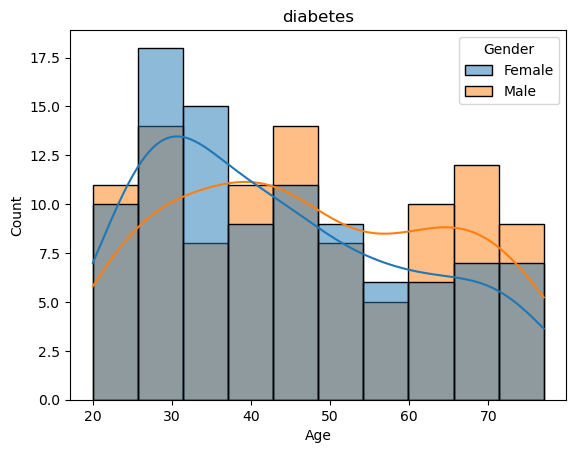

In [607]:
#barchart
import matplotlib.pyplot as plt
import seaborn as sns
sns.histplot(data=df,x='Age',bins=10,color='skyblue',kde='True',hue='Gender')
plt.title('diabetes')
plt.show()

# Correlation Heatmap

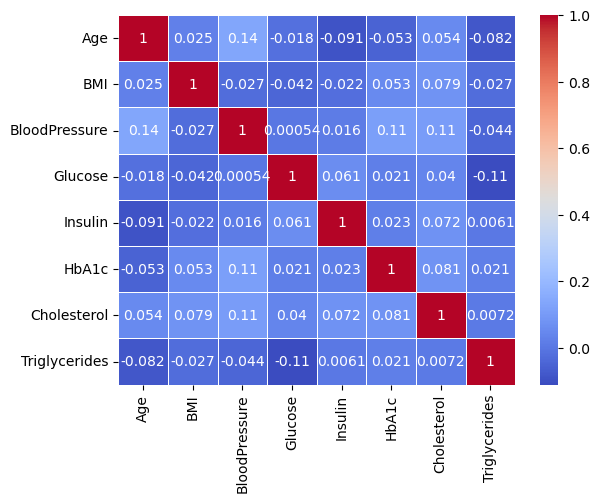

In [608]:
#heatmap
import matplotlib.pyplot as plt
import seaborn as sns
data=pd.DataFrame(df)
corr=df.corr()
sns.heatmap(corr,annot=True,cmap='coolwarm',linewidth=0.5) 
plt.show()

# Feature Engineering

In [609]:
def BMI(x):
    if x < 18.5:
        return 'Underweight'
    elif x < 25:
        return 'Normal'
    elif x < 30:
        return 'Overweight'
    else:
        return 'Obese'

df['BMI_Category'] = df['BMI'].apply(BMI)

In [610]:
def BP_Category(bp):
    if bp < 120 and bp< 80:
        return 0   # Normal
    elif bp < 140:
        return 1   # Pre-Hypertension
    else:
        return 2   # Hypertension

df['BP_Category'] = df['BloodPressure'].apply(BP_Category)

In [611]:
def chol_risk(x):
    if x < 200:
        return 0   # Normal
    elif x < 240:
        return 1   # Borderline
    else:
        return 2   # High
df['Cholesterol_Risk'] = df['Cholesterol'].apply(chol_risk)

In [612]:
df

,Age,Gender,BMI,BloodPressure,Glucose,Insulin,HbA1c,Cholesterol,Triglycerides,Smoking,PhysicalActivity,FamilyHistory,Outcome,BMI_Category,BP_Category,Cholesterol_Risk
0,57,Female,30.1,171,167,49,9.9,241,56,Yes,Moderate,Yes,Non-Diabetic,Obese,2,2
1,63,Male,38.4,135,103,249,9.4,277,165,Yes,Low,Yes,Non-Diabetic,Obese,1,2
2,32,Female,38.2,163,84,235,8.5,197,216,No,Moderate,No,Non-Diabetic,Obese,2,0
3,28,Female,26.7,85,147,225,4.6,130,209,No,Low,No,Diabetic,Overweight,1,0
4,29,Female,39.2,121,131,79,8.3,264,112,Yes,Moderate,No,Diabetic,Obese,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,73,Female,18.7,97,147,225,6.3,211,150,Yes,Moderate,No,Diabetic,Normal,1,1
196,40,Male,33.6,103,112,135,6.8,202,226,No,Low,Yes,Diabetic,Obese,1,1
197,30,Male,28.2,142,105,221,12.4,238,102,No,High,No,Non-Diabetic,Overweight,2,1
198,52,Female,38.8,138,145,131,10.8,284,142,Yes,High,Yes,Non-Diabetic,Obese,1,2


# Feature Encoding

In [613]:
from sklearn.preprocessing import LabelEncoder 
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
le=LabelEncoder()
df['Gender']=le.fit_transform(df['Gender'])
df['Outcome']=le.fit_transform(df['Outcome'])
df['Smoking']=le.fit_transform(df['Smoking'])
df['PhysicalActivity']=le.fit_transform(df['PhysicalActivity'])


In [614]:
df['BMI_Category']=le.fit_transform(df['BMI_Category'])


In [615]:
df['FamilyHistory']=le.fit_transform(df['FamilyHistory'])


# Feature Selection

In [616]:

# X = features, y = target
XD = df.drop('Outcome',axis=1)
yD = df['Outcome']


# Train-test split

In [617]:
XD_train, XD_test, yD_train, yD_test = train_test_split( XD, yD, test_size=0.2, random_state=42)


# Feature Scaling

In [618]:
# Feature Scaling
scaler = StandardScaler()
XD_train = scaler.fit_transform(XD_train)
XD_test = scaler.transform(XD_test)

# Target

In [619]:
df['Outcome'].value_counts()

1    111
0     89
Name: Outcome, dtype: int64

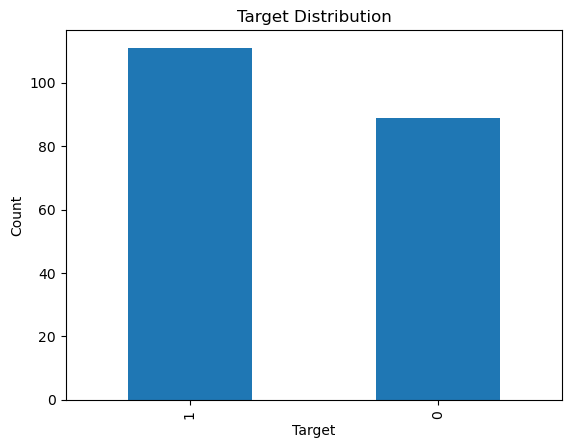

In [620]:
import matplotlib.pyplot as plt
import seaborn as sns
df['Outcome'].value_counts().plot(kind='bar')
plt.title("Target Distribution")
plt.xlabel("Target")
plt.ylabel("Count")
plt.show()

# Logistic Regression

In [621]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [622]:
diabetes_model = LogisticRegression()

diabetes_model.fit(XD_train, yD_train)

LogisticRegression()

In [623]:
yD_pred = diabetes_model.predict(XD_test)

In [624]:
print("Accuracy:", accuracy_score(yD_test, yD_pred))
print("Confusion Matrix:\n", confusion_matrix(yD_test, yD_pred))
print("Classification Report:\n", classification_report(yD_test, yD_pred))

Accuracy: 0.575
Confusion Matrix:
 [[ 7 11]
 [ 6 16]]
Classification Report:
               precision    recall  f1-score   support

           0       0.54      0.39      0.45        18
           1       0.59      0.73      0.65        22

    accuracy                           0.57        40
   macro avg       0.57      0.56      0.55        40
weighted avg       0.57      0.57      0.56        40



# confusion matrix

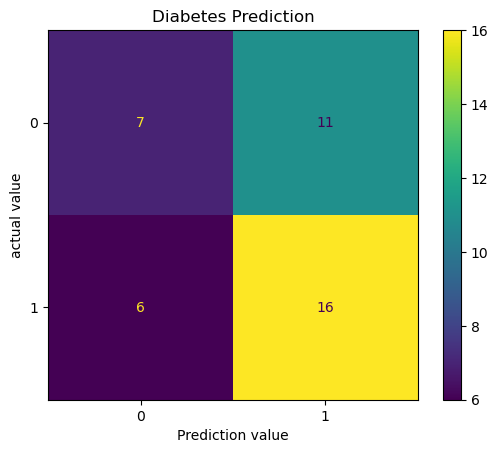

In [625]:

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Create confusion matrix
cm = confusion_matrix(yD_test, yD_pred)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()
plt.title("Diabetes Prediction")
plt.xlabel("Prediction value")
plt.ylabel("actual value")
plt.show()

# Load Dataset of Heart disease

In [658]:
#heart dataset
import pandas as pd
dh=pd.read_csv('heart (2).csv')


In [659]:
dh

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


In [660]:
dh

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


# Exploratory Data Analysis

In [661]:
dh.iloc[ :200]

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,59,1,2,150,212,1,1,157,0,1.6,2,0,2,1
196,58,1,0,100,234,0,1,156,0,0.1,2,1,3,0
197,45,1,0,115,260,0,0,185,0,0.0,2,0,2,1
198,60,0,2,102,318,0,1,160,0,0.0,2,1,2,1


In [662]:
dh.drop(dh.index[-800:],inplace=True)

In [663]:
dh

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
220,57,0,1,130,236,0,0,174,0,0.0,1,1,2,0
221,63,1,0,130,254,0,0,147,0,1.4,1,1,3,0
222,64,1,3,110,211,0,0,144,1,1.8,1,0,2,1
223,39,0,2,94,199,0,1,179,0,0.0,2,0,2,1


In [664]:
dh.duplicated().sum()

57

In [665]:
dh[dh.duplicated()]

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
15,34,0,1,118,210,0,1,192,0,0.7,2,0,2,1
31,50,0,1,120,244,0,1,162,0,1.1,2,0,2,1
43,46,1,0,120,249,0,0,144,0,0.8,2,0,3,0
55,55,1,0,140,217,0,1,111,1,5.6,0,0,3,0
61,66,0,2,146,278,0,0,152,0,0.0,1,1,2,1
64,29,1,1,130,204,0,0,202,0,0.0,2,0,2,1
79,52,1,1,134,201,0,1,158,0,0.8,2,1,2,1
82,46,1,2,150,231,0,1,147,0,3.6,1,0,2,0
83,38,1,2,138,175,0,1,173,0,0.0,2,4,2,1
84,37,0,2,120,215,0,1,170,0,0.0,2,0,2,1


In [666]:
print(dh.isnull().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [667]:
print(dh['sex'].unique())
print(dh['sex'].isnull().sum())

[1 0]
0


In [668]:
#statical columns
dh.min()

age          29.0
sex           0.0
cp            0.0
trestbps     94.0
chol        126.0
fbs           0.0
restecg       0.0
thalach      88.0
exang         0.0
oldpeak       0.0
slope         0.0
ca            0.0
thal          0.0
target        0.0
dtype: float64

In [669]:
dh.max()


age          77.0
sex           1.0
cp            3.0
trestbps    200.0
chol        564.0
fbs           1.0
restecg       2.0
thalach     202.0
exang         1.0
oldpeak       6.2
slope         2.0
ca            4.0
thal          3.0
target        1.0
dtype: float64

In [670]:
dh.var()

age           88.402063
sex            0.187778
cp             1.082421
trestbps     311.462302
chol        3527.057540
fbs            0.138016
restecg        0.286587
thalach      514.410000
exang          0.228849
oldpeak        1.640485
slope          0.425714
ca             0.995754
thal           0.383214
target         0.250992
dtype: float64

In [671]:
dh.std()

age          9.402237
sex          0.433333
cp           1.040394
trestbps    17.648295
chol        59.389036
fbs          0.371505
restecg      0.535338
thalach     22.680608
exang        0.478382
oldpeak      1.280814
slope        0.652468
ca           0.997875
thal         0.619043
target       0.500991
dtype: float64

In [672]:
dh.count()

age         225
sex         225
cp          225
trestbps    225
chol        225
fbs         225
restecg     225
thalach     225
exang       225
oldpeak     225
slope       225
ca          225
thal        225
target      225
dtype: int64

In [673]:
dh.value_counts()

age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  ca  thal  target
54   1    1   108       309   0    1        156      0      0.0      2      0   3     1         4
29   1    1   130       204   0    0        202      0      0.0      2      0   2     1         3
63   1    0   140       187   0    0        144      1      4.0      2      2   3     0         3
54   1    2   120       258   0    0        147      0      0.4      1      0   3     1         3
44   1    0   120       169   0    1        144      1      2.8      0      0   1     0         3
                                                                                               ..
54   1    0   124       266   0    0        109      1      2.2      1      1   3     0         1
43   1    0   150       247   0    1        171      0      1.5      2      0   2     1         1
54   1    0   110       239   0    1        126      1      2.8      1      1   3     0         1
                        2

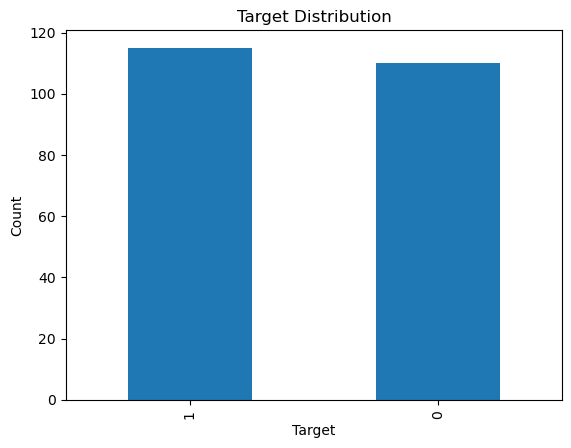

In [674]:
import matplotlib.pyplot as plt
import seaborn as sns
dh['target'].value_counts().plot(kind='bar')
plt.title("Target Distribution")
plt.xlabel("Target")
plt.ylabel("Count")
plt.show()

In [675]:
dh.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,225.000000,225.000000,225.000000,225.000000,225.000000,225.000000,225.000000,225.000000,225.000000,225.000000,225.000000,225.000000,225.000000,225.000000
mean,53.528889,0.751111,0.951111,131.355556,247.977778,0.164444,0.484444,150.693333,0.351111,1.115111,1.386667,0.702222,2.306667,0.511111
std,9.402237,0.433333,1.040394,17.648295,59.389036,0.371505,0.535338,22.680608,0.478382,1.280814,0.652468,0.997875,0.619043,0.500991
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,88.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,46.000000,1.000000,0.000000,120.000000,206.000000,0.000000,0.000000,140.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,54.000000,1.000000,1.000000,130.000000,244.000000,0.000000,0.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,60.000000,1.000000,2.000000,140.000000,286.000000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [676]:
dh.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 225 entries, 0 to 224
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       225 non-null    int64  
 1   sex       225 non-null    int64  
 2   cp        225 non-null    int64  
 3   trestbps  225 non-null    int64  
 4   chol      225 non-null    int64  
 5   fbs       225 non-null    int64  
 6   restecg   225 non-null    int64  
 7   thalach   225 non-null    int64  
 8   exang     225 non-null    int64  
 9   oldpeak   225 non-null    float64
 10  slope     225 non-null    int64  
 11  ca        225 non-null    int64  
 12  thal      225 non-null    int64  
 13  target    225 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 24.7 KB


In [677]:
dh.sum()

age         12044.0
sex           169.0
cp            214.0
trestbps    29555.0
chol        55795.0
fbs            37.0
restecg       109.0
thalach     33906.0
exang          79.0
oldpeak       250.9
slope         312.0
ca            158.0
thal          519.0
target        115.0
dtype: float64

In [678]:
dh.quantile()

age          54.0
sex           1.0
cp            1.0
trestbps    130.0
chol        244.0
fbs           0.0
restecg       0.0
thalach     152.0
exang         0.0
oldpeak       0.8
slope         1.0
ca            0.0
thal          2.0
target        1.0
Name: 0.5, dtype: float64

In [679]:
dh.nunique()

age          39
sex           2
cp            4
trestbps     43
chol        118
fbs           2
restecg       3
thalach      79
exang         2
oldpeak      35
slope         3
ca            5
thal          4
target        2
dtype: int64

In [680]:
dh['chol'].unique()

array([212, 203, 174, 294, 248, 318, 289, 249, 286, 149, 341, 210, 298,
       204, 308, 266, 244, 211, 185, 223, 208, 252, 209, 307, 233, 319,
       256, 327, 169, 131, 269, 196, 231, 213, 271, 263, 229, 360, 258,
       330, 342, 226, 228, 278, 230, 283, 241, 175, 188, 217, 193, 245,
       232, 299, 288, 197, 315, 215, 164, 326, 207, 177, 257, 255, 187,
       201, 220, 268, 267, 236, 303, 282, 126, 309, 186, 275, 281, 206,
       335, 218, 254, 295, 417, 260, 240, 302, 192, 225, 325, 235, 274,
       234, 182, 167, 172, 321, 300, 199, 564, 157, 304, 222, 184, 354,
       160, 247, 239, 246, 409, 293, 180, 250, 221, 200, 227, 243, 311,
       261], dtype=int64)

# Age distribution in Heart Dataset (Male[1] vs female[0])

In [681]:
import matplotlib.pyplot as plt
import seaborn as sns


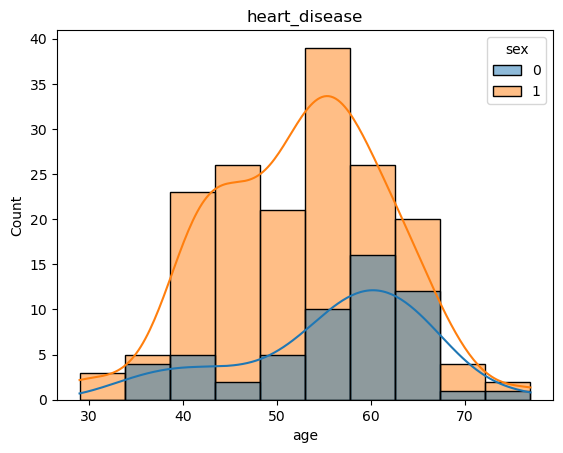

In [682]:
sns.histplot(data=dh,bins=10,x='age',hue='sex',kde=True,color='skyblue')
plt.title('heart_disease')
plt.show()

In [683]:
print(dh.columns)

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')


In [684]:
XH = dh.drop('target',axis=1)
yH = dh['target']
#encode categorical variables
xH=pd.get_dummies(XH, drop_first=True)




# Train_Test split

In [685]:
XH_train, XH_test, yH_train, yH_test = train_test_split( XH, yH, test_size=0.2, random_state=42)


In [686]:
dh['target'].value_counts()


1    115
0    110
Name: target, dtype: int64

# Feature Engineering

In [687]:
def hr_level(x):
    if x > 150:
        return 'High'
    elif x > 100:
        return 'Normal'
    else:
        return 'Low'

dh['HR_Level'] = dh['thalach'].apply(hr_level)

In [688]:
def st_severity(x):
    if x < 1:
        return 'Mild'
    elif x < 2:
        return 'Moderate'
    else:
        return 'Severe'

dh['ST_Severity'] = dh['oldpeak'].apply(st_severity)

# Feature Encoding

In [689]:
from sklearn.preprocessing import LabelEncoder 
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
le=LabelEncoder()


In [690]:
dh['HR_Level']=le.fit_transform(dh['HR_Level'])
dh['ST_Severity']=le.fit_transform(dh['ST_Severity'])


In [691]:


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


# Feature Selection

In [692]:
XH=dh.drop('target', axis=1)
yH=dh['target']

# Feature Scaling

In [693]:
scaler = StandardScaler()
XH_train = scaler.fit_transform(XH_train)
XH_test = scaler.transform(XH_test)

In [694]:
print(dh.columns)

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target', 'HR_Level',
       'ST_Severity'],
      dtype='object')


# Support vector machine

In [695]:
heart_model = SVC(kernel='rbf',probability=True)
heart_model.fit(XH_train, yH_train)


SVC(probability=True)

In [696]:
yh_pred = heart_model.predict(XH_test)


In [697]:
# Accuracy
acc = accuracy_score(yH_test, yh_pred)
print("Accuracy:", acc)

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(yH_test, yh_pred))

# Classification Report
print("\nClassification Report:")
print(classification_report(yH_test, yh_pred))


Accuracy: 0.9111111111111111

Confusion Matrix:
[[12  3]
 [ 1 29]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.80      0.86        15
           1       0.91      0.97      0.94        30

    accuracy                           0.91        45
   macro avg       0.91      0.88      0.90        45
weighted avg       0.91      0.91      0.91        45



# Confusion matrix

In [698]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


In [699]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


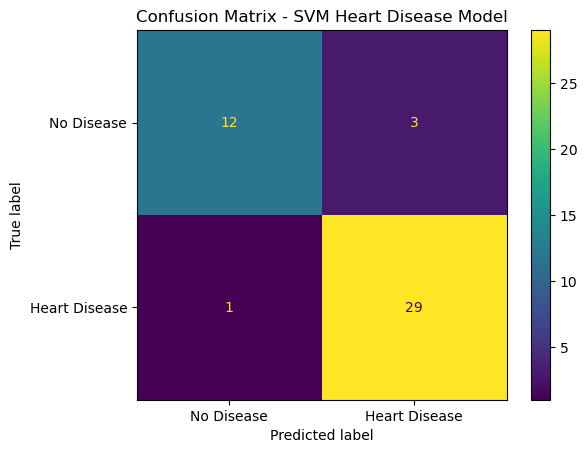

In [700]:
ch=confusion_matrix(yH_test,yh_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=ch,display_labels=["No Disease", "Heart Disease"])
disp.plot()
plt.title("Confusion Matrix - SVM Heart Disease Model")
plt.show()


# Load Dataset of Parkinson's Disease

In [701]:
import pandas as pd
dp=pd.read_csv('parkinsons_disease_data.csv')

In [704]:
dp

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,FunctionalAssessment,Tremor,Rigidity,Bradykinesia,PosturalInstability,SpeechProblems,SleepDisorders,Constipation,Diagnosis,DoctorInCharge
0,3058,85,0,3,1,19.619878,0,5.108241,1.380660,3.893969,...,1.572427,1,0,0,0,0,0,0,0,DrXXXConfid
1,3059,75,0,0,2,16.247339,1,6.027648,8.409804,8.513428,...,4.787551,0,1,0,1,0,1,0,1,DrXXXConfid
2,3060,70,1,0,0,15.368239,0,2.242135,0.213275,6.498805,...,2.130686,1,0,0,0,1,0,1,1,DrXXXConfid
3,3061,52,0,0,0,15.454557,0,5.997788,1.375045,6.715033,...,3.391288,1,1,1,0,0,0,1,1,DrXXXConfid
4,3062,87,0,0,1,18.616042,0,9.775243,1.188607,4.657572,...,3.200969,0,0,0,1,0,1,0,0,DrXXXConfid
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2100,5158,87,1,0,2,38.483841,0,12.674393,5.325900,5.947278,...,8.076254,1,0,0,0,1,1,0,0,DrXXXConfid
2101,5159,67,0,0,1,33.694396,1,0.977018,0.108599,4.825187,...,1.665751,0,0,0,1,0,1,1,1,DrXXXConfid
2102,5160,65,0,0,2,22.829631,0,6.152286,5.775103,0.334244,...,4.785614,0,0,0,0,1,1,0,1,DrXXXConfid
2103,5161,61,1,0,0,16.871030,1,0.292094,2.280475,9.598513,...,8.378979,1,0,1,0,0,1,1,1,DrXXXConfid


In [705]:
dp.drop(dp.index[-1600: ],inplace=True)

In [706]:
dp = dp.drop(['PatientID', 'DoctorInCharge'], axis=1)

In [707]:
dp.duplicated().sum()

0

In [708]:
dp.isnull().sum()

Age                         0
Gender                      0
Ethnicity                   0
EducationLevel              0
BMI                         0
Smoking                     0
AlcoholConsumption          0
PhysicalActivity            0
DietQuality                 0
SleepQuality                0
FamilyHistoryParkinsons     0
TraumaticBrainInjury        0
Hypertension                0
Diabetes                    0
Depression                  0
Stroke                      0
SystolicBP                  0
DiastolicBP                 0
CholesterolTotal            0
CholesterolLDL              0
CholesterolHDL              0
CholesterolTriglycerides    0
UPDRS                       0
MoCA                        0
FunctionalAssessment        0
Tremor                      0
Rigidity                    0
Bradykinesia                0
PosturalInstability         0
SpeechProblems              0
SleepDisorders              0
Constipation                0
Diagnosis                   0
dtype: int

In [709]:
dp.min()

Age                          50.000000
Gender                        0.000000
Ethnicity                     0.000000
EducationLevel                0.000000
BMI                          15.038069
Smoking                       0.000000
AlcoholConsumption            0.061815
PhysicalActivity              0.018781
DietQuality                   0.000011
SleepQuality                  4.018644
FamilyHistoryParkinsons       0.000000
TraumaticBrainInjury          0.000000
Hypertension                  0.000000
Diabetes                      0.000000
Depression                    0.000000
Stroke                        0.000000
SystolicBP                   90.000000
DiastolicBP                  60.000000
CholesterolTotal            150.186554
CholesterolLDL               50.242766
CholesterolHDL               20.054467
CholesterolTriglycerides     50.266089
UPDRS                         1.181777
MoCA                          0.037791
FunctionalAssessment          0.021356
Tremor                   

In [710]:
dp[dp.duplicated()]

,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,...,MoCA,FunctionalAssessment,Tremor,Rigidity,Bradykinesia,PosturalInstability,SpeechProblems,SleepDisorders,Constipation,Diagnosis


In [711]:
dp.max()

Age                          89.000000
Gender                        1.000000
Ethnicity                     3.000000
EducationLevel                3.000000
BMI                          39.968339
Smoking                       1.000000
AlcoholConsumption           19.988866
PhysicalActivity              9.995049
DietQuality                   9.995864
SleepQuality                  9.991139
FamilyHistoryParkinsons       1.000000
TraumaticBrainInjury          1.000000
Hypertension                  1.000000
Diabetes                      1.000000
Depression                    1.000000
Stroke                        1.000000
SystolicBP                  179.000000
DiastolicBP                 119.000000
CholesterolTotal            299.536680
CholesterolLDL              199.690639
CholesterolHDL               99.874766
CholesterolTriglycerides    399.936599
UPDRS                       198.953604
MoCA                         29.959826
FunctionalAssessment          9.990216
Tremor                   

In [712]:
dp.var()

Age                           123.613571
Gender                          0.249780
Ethnicity                       1.038425
EducationLevel                  0.773833
BMI                            56.035656
Smoking                         0.200770
AlcoholConsumption             31.932432
PhysicalActivity                8.301607
DietQuality                     8.124665
SleepQuality                    3.195394
FamilyHistoryParkinsons         0.149285
TraumaticBrainInjury            0.084575
Hypertension                    0.115299
Diabetes                        0.121067
Depression                      0.162683
Stroke                          0.048931
SystolicBP                    698.742951
DiastolicBP                   266.176332
CholesterolTotal             1895.682861
CholesterolLDL               1886.165860
CholesterolHDL                546.673145
CholesterolTriglycerides    10076.849334
UPDRS                        3138.761294
MoCA                           73.193856
FunctionalAssess

In [713]:
dp.std()

Age                          11.118164
Gender                        0.499780
Ethnicity                     1.019032
EducationLevel                0.879678
BMI                           7.485697
Smoking                       0.448074
AlcoholConsumption            5.650879
PhysicalActivity              2.881251
DietQuality                   2.850380
SleepQuality                  1.787566
FamilyHistoryParkinsons       0.386374
TraumaticBrainInjury          0.290818
Hypertension                  0.339558
Diabetes                      0.347947
Depression                    0.403339
Stroke                        0.221204
SystolicBP                   26.433746
DiastolicBP                  16.314911
CholesterolTotal             43.539440
CholesterolLDL               43.430011
CholesterolHDL               23.381042
CholesterolTriglycerides    100.383511
UPDRS                        56.024649
MoCA                          8.555341
FunctionalAssessment          3.032794
Tremor                   

In [714]:
dp.count()

Age                         505
Gender                      505
Ethnicity                   505
EducationLevel              505
BMI                         505
Smoking                     505
AlcoholConsumption          505
PhysicalActivity            505
DietQuality                 505
SleepQuality                505
FamilyHistoryParkinsons     505
TraumaticBrainInjury        505
Hypertension                505
Diabetes                    505
Depression                  505
Stroke                      505
SystolicBP                  505
DiastolicBP                 505
CholesterolTotal            505
CholesterolLDL              505
CholesterolHDL              505
CholesterolTriglycerides    505
UPDRS                       505
MoCA                        505
FunctionalAssessment        505
Tremor                      505
Rigidity                    505
Bradykinesia                505
PosturalInstability         505
SpeechProblems              505
SleepDisorders              505
Constipa

In [715]:
dp.sum()

Age                          34937.000000
Gender                         266.000000
Ethnicity                      360.000000
EducationLevel                 693.000000
BMI                          13780.308621
Smoking                        140.000000
AlcoholConsumption            5006.218560
PhysicalActivity              2663.297115
DietQuality                   2641.842496
SleepQuality                  3559.829714
FamilyHistoryParkinsons         92.000000
TraumaticBrainInjury            47.000000
Hypertension                    67.000000
Diabetes                        71.000000
Depression                     103.000000
Stroke                          26.000000
SystolicBP                   67193.000000
DiastolicBP                  46015.000000
CholesterolTotal            114519.095863
CholesterolLDL               62570.071665
CholesterolHDL               29217.958747
CholesterolTriglycerides    113163.246170
UPDRS                        50988.227328
MoCA                          7915

In [716]:
dp.nunique()

Age                          40
Gender                        2
Ethnicity                     4
EducationLevel                4
BMI                         505
Smoking                       2
AlcoholConsumption          505
PhysicalActivity            505
DietQuality                 505
SleepQuality                505
FamilyHistoryParkinsons       2
TraumaticBrainInjury          2
Hypertension                  2
Diabetes                      2
Depression                    2
Stroke                        2
SystolicBP                   89
DiastolicBP                  60
CholesterolTotal            505
CholesterolLDL              505
CholesterolHDL              505
CholesterolTriglycerides    505
UPDRS                       505
MoCA                        505
FunctionalAssessment        505
Tremor                        2
Rigidity                      2
Bradykinesia                  2
PosturalInstability           2
SpeechProblems                2
SleepDisorders                2
Constipa

In [717]:
dp['Diabetes'].unique()

array([0, 1], dtype=int64)

In [718]:
dp.quantile()

Age                          69.000000
Gender                        1.000000
Ethnicity                     0.000000
EducationLevel                1.000000
BMI                          27.757648
Smoking                       0.000000
AlcoholConsumption            9.900395
PhysicalActivity              5.521453
DietQuality                   5.268176
SleepQuality                  6.970444
FamilyHistoryParkinsons       0.000000
TraumaticBrainInjury          0.000000
Hypertension                  0.000000
Diabetes                      0.000000
Depression                    0.000000
Stroke                        0.000000
SystolicBP                  133.000000
DiastolicBP                  93.000000
CholesterolTotal            226.160054
CholesterolLDL              120.270993
CholesterolHDL               56.614982
CholesterolTriglycerides    223.065526
UPDRS                       100.236996
MoCA                         15.946031
FunctionalAssessment          5.195544
Tremor                   

# Histogram

In [719]:
import matplotlib.pyplot as plt
import seaborn as sns

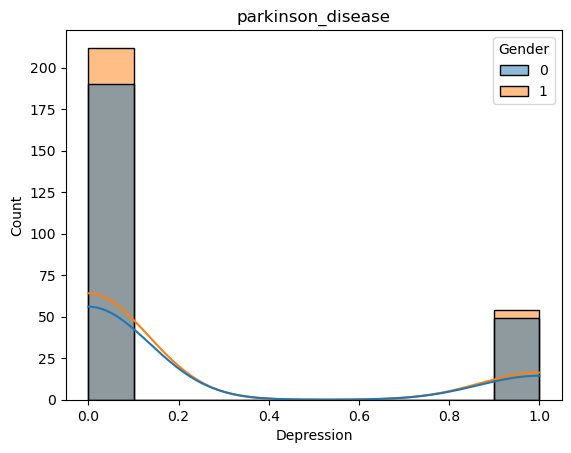

In [720]:
sns.histplot(data=dp,color='skyblue',hue='Gender',x='Depression',kde=True,bins=10)
plt.title('parkinson_disease')
plt.show()

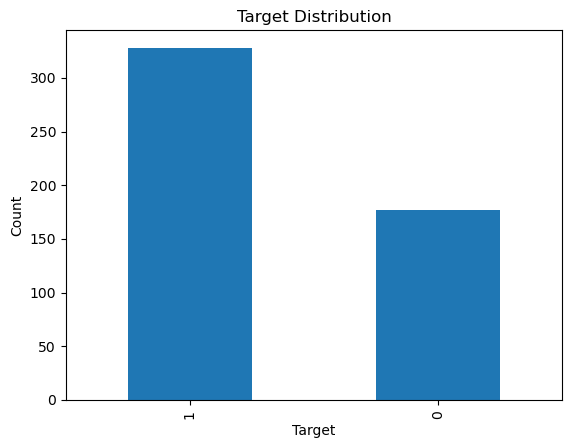

In [721]:
import matplotlib.pyplot as plt
import seaborn as sns
dp['Diagnosis'].value_counts().plot(kind='bar')
plt.title("Target Distribution")
plt.xlabel("Target")
plt.ylabel("Count")
plt.show()

In [722]:
from sklearn.preprocessing import StandardScaler

# Feature Engineering

In [723]:
dp['Motor_Score'] = (
    dp['Tremor'] +
    dp['Rigidity'] +
    dp['Bradykinesia'] +
    dp['PosturalInstability']
)

In [724]:
dp['Early_Symptoms'] = (
    (dp['Tremor'] == 1) |
    (dp['SleepDisorders'] == 1)
).astype(int)

# Feature selection

In [725]:

Xp = dp.drop('Diagnosis',axis=1)
yp = dp['Diagnosis']


# Train_Test split

In [726]:
Xp_train, Xp_test, yp_train, yp_test = train_test_split( Xp, yp, test_size=0.2, random_state=42)



# Feature Scaling

In [727]:
scaler = StandardScaler()
Xp_train = scaler.fit_transform(Xp_train)
Xp_test= scaler.transform(Xp_test)

# Decision Tree

In [728]:

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [729]:
parkinson_model = DecisionTreeClassifier(criterion='gini', max_depth=5, random_state=42)

In [730]:
parkinson_model.fit(Xp_train, yp_train)


DecisionTreeClassifier(max_depth=5, random_state=42)

In [731]:
yp_pred = parkinson_model.predict(Xp_test)


In [732]:
print("Accuracy:", accuracy_score(yp_test, yp_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(yp_test, yp_pred))

print("\nClassification Report:")
print(classification_report(yp_test, yp_pred))


Accuracy: 0.9207920792079208

Confusion Matrix:
[[35  1]
 [ 7 58]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.97      0.90        36
           1       0.98      0.89      0.94        65

    accuracy                           0.92       101
   macro avg       0.91      0.93      0.92       101
weighted avg       0.93      0.92      0.92       101



# Confusion Matrix

In [733]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


In [734]:
cp = confusion_matrix(yp_test, yp_pred)
print(cp)


[[35  1]
 [ 7 58]]


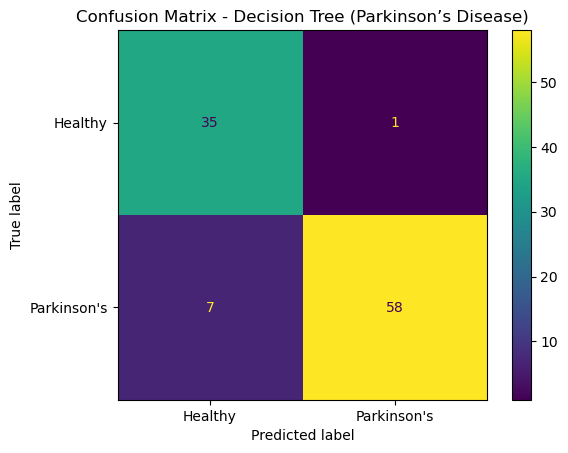

In [735]:
disp = ConfusionMatrixDisplay( confusion_matrix=cp,display_labels=["Healthy", "Parkinson's"])

disp.plot()
plt.title("Confusion Matrix - Decision Tree (Parkinson’s Disease)")
plt.show()


In [736]:
import pickle

In [737]:
pickle.dump(heart_model,open('heart_disease_model.sav','wb'))
print("Heart model saved")

Heart model saved


In [738]:
pickle.dump(diabetes_model,open('diabetes_disease_model.sav','wb'))
print("diabetes model saved")

diabetes model saved


In [739]:
pickle.dump(parkinson_model,open('parkinson_disease_model.sav','wb'))
print("parkinson model saved")

parkinson model saved


# Comparsion between models

In [740]:
diabetes_model = LogisticRegression()
diabetes_model.fit(XD_train, yD_train)

LogisticRegression()

In [741]:
parkinson_model = DecisionTreeClassifier(criterion='gini', max_depth=5, random_state=42)
parkinson_model.fit(Xp_train, yp_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [742]:
heart_model = SVC(kernel='rbf',probability=True)
heart_model.fit(XH_train, yH_train)

SVC(probability=True)

In [743]:
yp_pred = parkinson_model.predict(Xp_test)
yh_pred = heart_model.predict(XH_test)

In [744]:
yD_pred = diabetes_model.predict(XD_test)

In [745]:
print("logistic Regression acurray",accuracy_score(yD_test,yD_pred))
print("parkinson's model",accuracy_score(yp_test,yp_pred))
print("hear_disease",accuracy_score(yH_test,yh_pred))

logistic Regression acurray 0.575
parkinson's model 0.9207920792079208
hear_disease 0.9111111111111111


In [746]:
from sklearn.metrics import classification_report
print("logistic Regression acurray",classification_report(yD_test,yD_pred))
print("parkinson's model",classification_report(yp_test,yp_pred))
print("hear_disease",classification_report(yH_test,yh_pred))



logistic Regression acurray               precision    recall  f1-score   support

           0       0.54      0.39      0.45        18
           1       0.59      0.73      0.65        22

    accuracy                           0.57        40
   macro avg       0.57      0.56      0.55        40
weighted avg       0.57      0.57      0.56        40

parkinson's model               precision    recall  f1-score   support

           0       0.83      0.97      0.90        36
           1       0.98      0.89      0.94        65

    accuracy                           0.92       101
   macro avg       0.91      0.93      0.92       101
weighted avg       0.93      0.92      0.92       101

hear_disease               precision    recall  f1-score   support

           0       0.92      0.80      0.86        15
           1       0.91      0.97      0.94        30

    accuracy                           0.91        45
   macro avg       0.91      0.88      0.90        45
weighted avg   

In [747]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "SVM"],
    "Accuracy": [
        accuracy_score(yD_test,yD_pred),
        accuracy_score(yp_test,yp_pred),
        accuracy_score(yH_test,yh_pred )
    ]
})

print(results)

                 Model  Accuracy
0  Logistic Regression  0.575000
1        Random Forest  0.920792
2                  SVM  0.911111


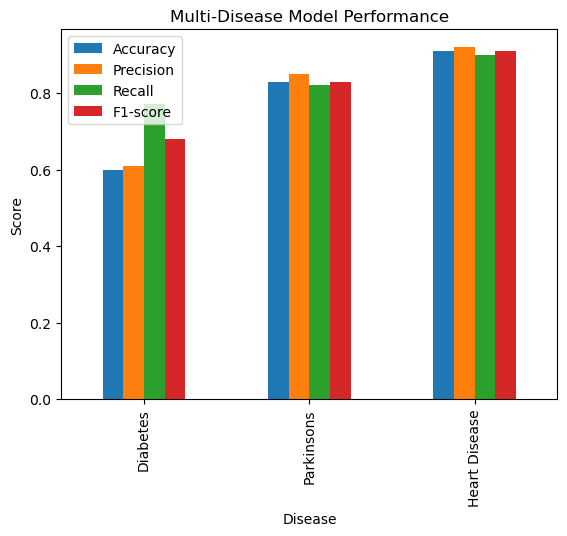

In [748]:
data = {
    'Disease': ['Diabetes', 'Parkinsons', 'Heart Disease'],
    'Accuracy': [0.60, 0.83, 0.91],
    'Precision': [0.61, 0.85, 0.92],
    'Recall': [0.77, 0.82, 0.90],
    'F1-score': [0.68, 0.83, 0.91]
}

df = pd.DataFrame(data)
df.set_index('Disease').plot(kind='bar')

plt.title("Multi-Disease Model Performance")
plt.ylabel("Score")

plt.show()